# Global_Temperature_Anomaly_Analysis

ANALISIS DE UN DATASET DE TEMPERATURA GLOBAL DESDE 1850

CARGA DE DATOS

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/Berk.GLBTSSST.long.csv",skiprows=1,names=["Date","Temperature"])

LIMPIEZA Y VERIFICACION DE DATOS

In [24]:
df.head()


,Date,Temperature
0,1850-01-01,-1.791
1,1850-02-01,-0.006
2,1850-03-01,-0.432
3,1850-04-01,-1.109
4,1850-05-01,-1.317


Tenemos dos columnas, Date y Temperature, fecha desde el 1 de enero de 1850 hasta diciembre de 2021. Temperature en centigrados con valores positivos y negativos, significa un promedio de las temperaturas de ese mes, en unos aumenta y en otros diminuye.

In [25]:
df.tail(10)

,Date,Temperature
2054,2021-03-01,1.412
2055,2021-04-01,1.167
2056,2021-05-01,1.022
2057,2021-06-01,1.190
2058,2021-07-01,1.343
2059,2021-08-01,0.000
2060,2021-09-01,0.000
2061,2021-10-01,0.000
2062,2021-11-01,0.000
2063,2021-12-01,0.000


Los ultimos 5 valores estan en ceros ya que no se han añadido al dataset cuando fue cargado.

In [26]:
df.shape

(2064, 2)

El dataset consta de 2064 filas y 2 columnas.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2064 non-null   object 
 1   Temperature  2064 non-null   float64
dtypes: float64(1), object(1)
memory usage: 32.4+ KB


La informacion del dataset es la siguiente:
una columna es llave primaria de conteo.
La columna 0 es Date con tipo objeto, la cual cambiare a datetime por motivos de analisis.
La columna temperature esta en flotante, es correcto su valor de dato.


In [28]:
df["Date"] = pd.to_datetime(df["Date"])

In [29]:
df.describe()

,Date,Temperature
count,2064,2064.000000
mean,1935-12-16 18:00:00,0.000980
min,1850-01-01 00:00:00,-2.035000
25%,1892-12-24 06:00:00,-0.375000
50%,1935-12-16 12:00:00,-0.066000
75%,1978-12-08 18:00:00,0.322250
max,2021-12-01 00:00:00,2.211000
std,NaN,0.610617


Los datos son coherentes, muestran un minimo desde 1850 hasta su maximo en 2021. La temperatura minima es -2.035 y la maxima es de 2.211. No se detecta valor extremo que altere el analisis a posteriori.

LIMPIEZA DE DATOS

In [30]:
df.isnull().sum()

,0
Date,0
Temperature,0


No se detectan valores nulos.

In [31]:
df.duplicated().sum()

np.int64(0)

No se detectan valores duplicados.

FEATURE ENGINEERING

In [32]:
df["Year"] = df["Date"].dt.year

In [33]:
df["Month"] = df["Date"].dt.month

In [34]:
df["Month_name"] = df["Date"].dt.month_name()

In [35]:
df["Decade"] = (df["Year"] // 10) * 10

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2064 non-null   datetime64[ns]
 1   Temperature  2064 non-null   float64       
 2   Year         2064 non-null   int32         
 3   Month        2064 non-null   int32         
 4   Month_name   2064 non-null   object        
 5   Decade       2064 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(1)
memory usage: 72.7+ KB


Añado columnas de tiempo para realizar un analisis mas profundo.

ANALISIS EXPLORATORIO DE DATOS EDA

In [37]:
df_year = df.groupby("Year")["Temperature"].mean().reset_index()

¿Cómo ha evolucionado la temperatura global desde 1850?

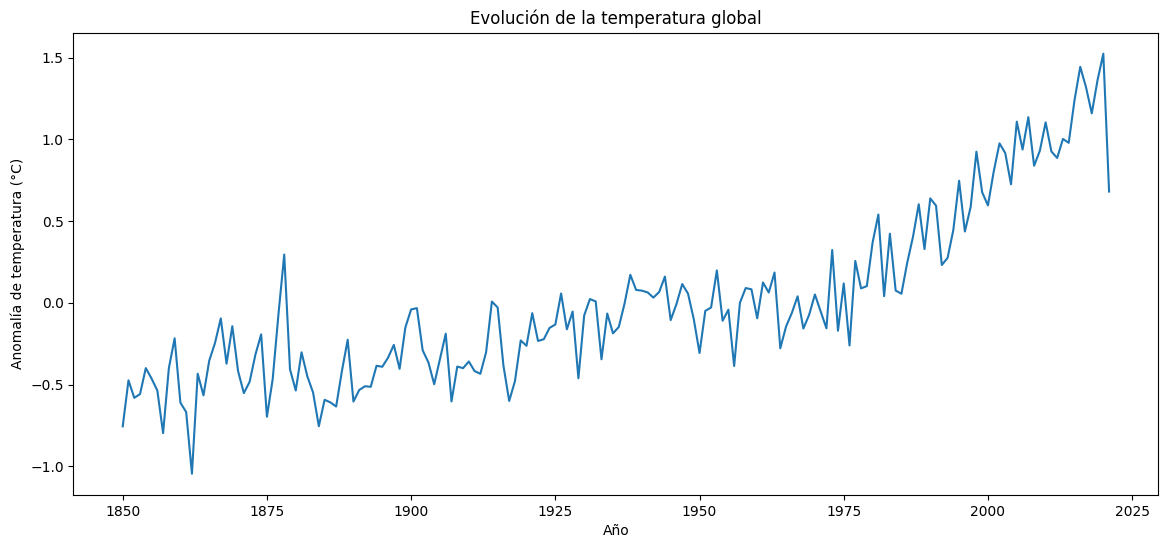

In [38]:
plt.figure(figsize=(14,6))
plt.plot(df_year["Year"],df_year["Temperature"])
plt.title("Evolución de la temperatura global")
plt.xlabel("Año")
plt.ylabel("Anomalía de temperatura (°C)")
plt.show()

La temperatura global presenta una tendencia creciente a lo largo del período analizado. Aunque existen fluctuaciones interanuales, las décadas recientes muestran anomalías de temperatura superiores a las observadas en el siglo XIX.


¿Cuáles fueron los 10 años más cálidos?

In [39]:
df_year.sort_values(by="Temperature",ascending=False).head(10)

,Year,Temperature
170,2020,1.523833
166,2016,1.443417
169,2019,1.362417
167,2017,1.319083
165,2015,1.237833
168,2018,1.158917
157,2007,1.135750
155,2005,1.108333
160,2010,1.103833
163,2013,1.002500


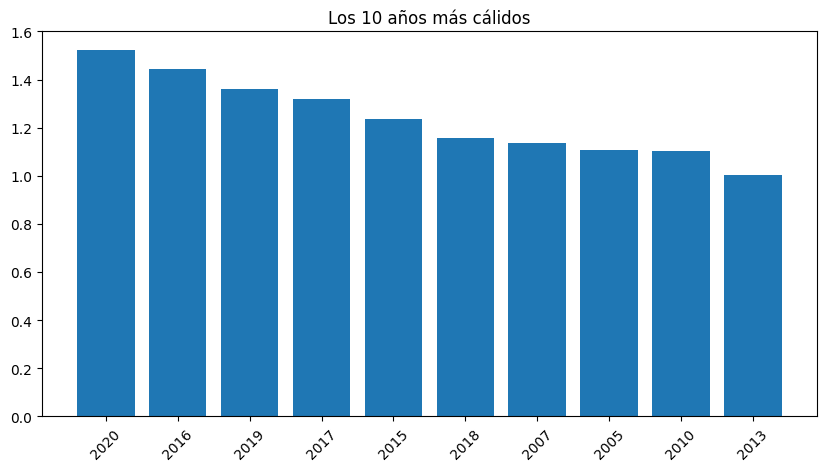

In [40]:
top10 = df_year.sort_values(by="Temperature",ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Year"].astype(str),top10["Temperature"])

plt.xticks(rotation=45)
plt.title("Los 10 años más cálidos")
plt.show()

Analizamos que los años mas calidos son de la ultimas dos decadas, superando registros desde 1850. La mayoria se encuentran en la ultima decada y corresponde a un aumento en las anomalias de temperatura medidas.

¿Cuáles fueron los años más fríos?

In [41]:
df_year.sort_values(by="Temperature").head(10)

,Year,Temperature
12,1862,-1.045167
7,1857,-0.796917
0,1850,-0.755500
34,1884,-0.754750
25,1875,-0.696583
11,1861,-0.668000
37,1887,-0.634000
10,1860,-0.610750
36,1886,-0.608750
40,1890,-0.603583


Analaizamos que los años mas frios son de las decadas posteriores a 1850, todas anteriores a los años 1900.

¿Qué década fue la más cálida?

In [46]:
df.groupby("Decade")["Temperature"].mean().reset_index().head(10)

,Decade,Temperature
0,1850,-0.518033
1,1860,-0.453225
2,1870,-0.330592
3,1880,-0.506983
4,1890,-0.408317
5,1900,-0.314850
6,1910,-0.322433
7,1920,-0.168617
8,1930,-0.054408
9,1940,0.035742


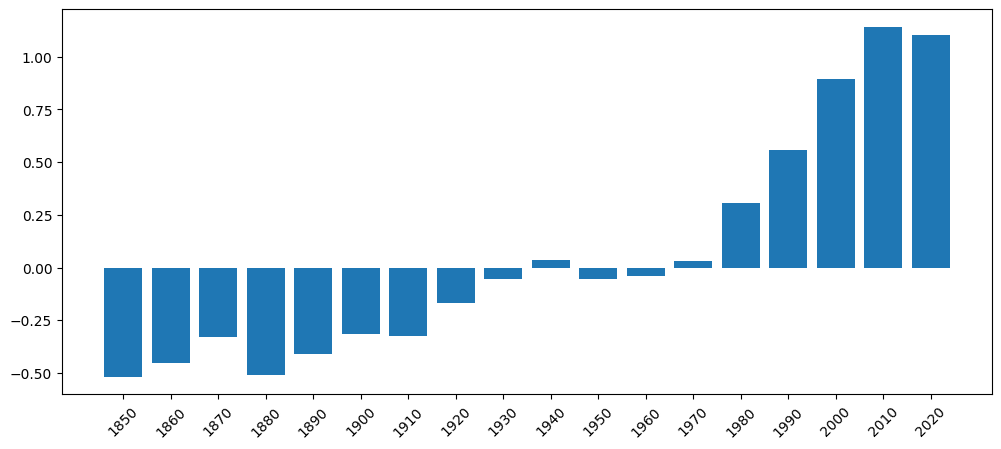

In [47]:
plt.figure(figsize=(12,5))

plt.bar(
    decadas["Decade"].astype(str),
    decadas["Temperature"]
)

plt.xticks(rotation=45)

plt.show()

Se detecta que las decadas mas calidas son las de 1980 en adelante, con una tendencia creciente, aunque en la ultima decada parece estabilizarce el incremento de temperatura.

¿Qué meses suelen ser más cálidos?

In [57]:
df.groupby("Month_name")["Temperature"].mean().head(10)

,Temperature
Month_name,
April,0.054453
August,0.014099
December,-0.007023
February,-0.056878
January,0.026221
July,0.073186
June,-0.021285
March,-0.085953
May,-0.038471


In [62]:
meses = (
    df.groupby("Month_name")["Temperature"].mean()
)

In [63]:
orden = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

meses = meses.reindex(orden)

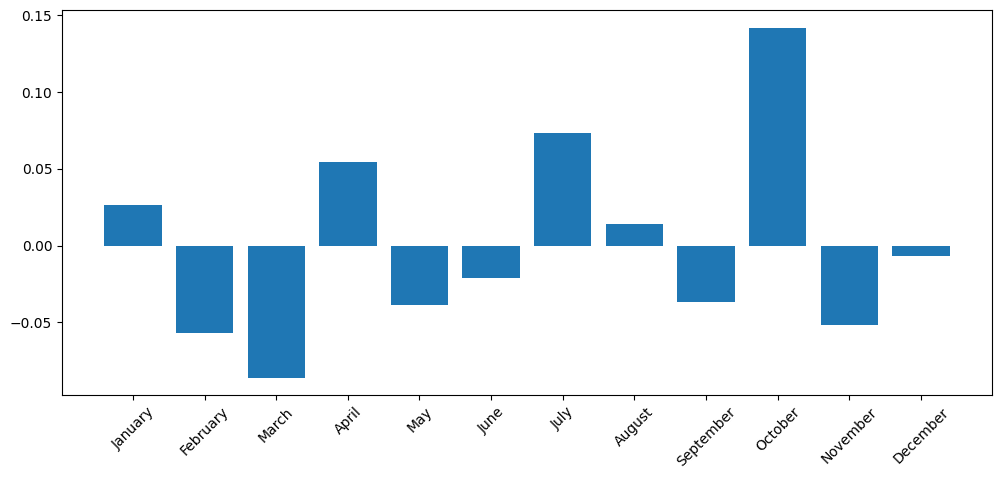

In [66]:
plt.figure(figsize=(12,5))
plt.bar(meses.index,meses.values)
plt.xticks(rotation=45)
plt.show()

En el promedio de anomalias de temperatura, marzo se presenta como tendiente a la mas fria y octubre a la mas calida.

¿Existe una tendencia de calentamiento?

In [69]:
import numpy as np

z = np.polyfit(
    df_year["Year"],
    df_year["Temperature"],
    1
)

p = np.poly1d(z)

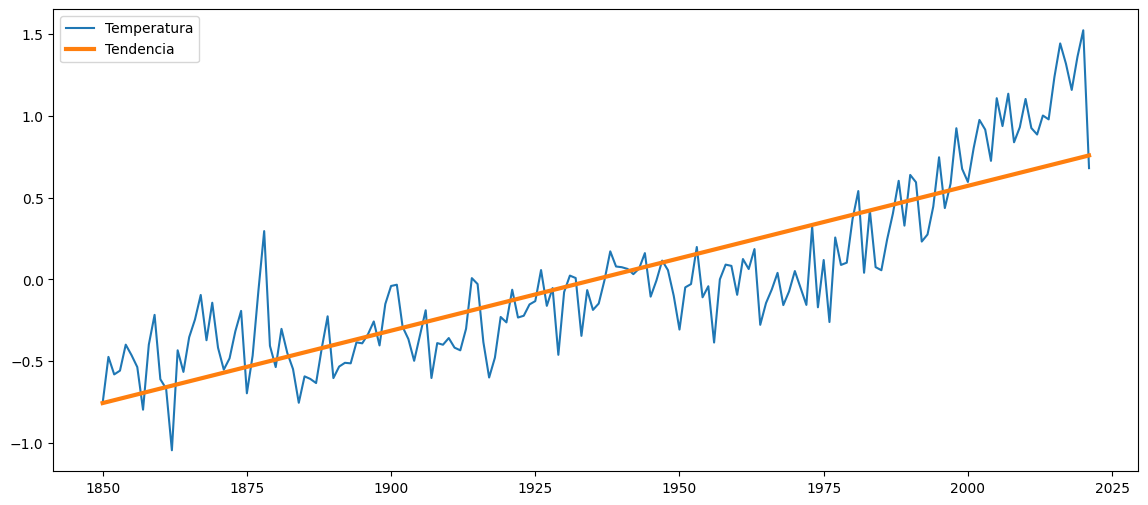

In [70]:
plt.figure(figsize=(14,6))

plt.plot(
    df_year["Year"],
    df_year["Temperature"],
    label="Temperatura"
)

plt.plot(
    df_year["Year"],
    p(df_year["Year"]),
    linewidth=3,
    label="Tendencia"
)

plt.legend()

plt.show()

se detecta una tendencia creciente clara desde 1850 hasta 2020 en la variacion de temperatura global.

distirbucion de temperatura

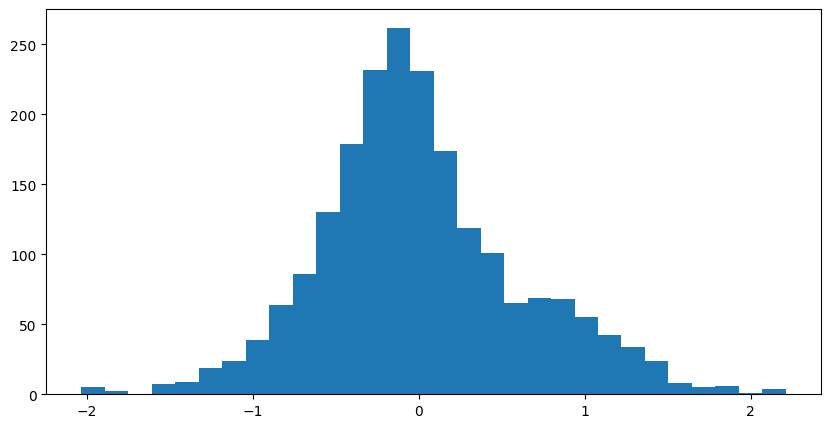

In [74]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Temperature"],
    bins=30
)

plt.show()

La distribución de las anomalías de temperatura presenta una forma aproximadamente normal, concentrándose la mayor parte de las observaciones entre -0.5 °C y 0.5 °C. Se observa una ligera asimetría hacia valores positivos, indicando que en las décadas recientes se han registrado anomalías cálidas más frecuentes e intensas que las anomalías frías.

conclusiones

Los resultados muestran una tendencia creciente de las anomalías de temperatura global desde 1850. Aunque existen fluctuaciones entre años, la tendencia general es ascendente, especialmente a partir de la década de 1980, cuando se observa un incremento más acelerado de las anomalías.

Durante las últimas dos décadas, las anomalías se mantienen en niveles históricamente elevados. Visualmente, el ritmo de crecimiento parece menos pronunciado que en el período de mayor aceleración; sin embargo, los valores continúan siendo superiores a los registrados en la mayor parte de la serie histórica.

En conjunto, el análisis evidencia un cambio sostenido en el comportamiento de la temperatura global a lo largo del tiempo, respaldando la existencia de un proceso de calentamiento reflejado en las anomalías de temperatura del conjunto de datos.

